In [1]:
import xarray as xr
from glob import glob
from datetime import datetime
import yaml
import sys
sys.path.append('../../')

import plotting

from conf.global_settings import OUTPUT_DIR
from utils.pipeline_utils.file_utils import get_date
from transformations.grid_transformation import Transformation

In [2]:
ds_name = "NASA_SSH_REF_ALONGTRACK_V11"
hemisphere = ''
with open(f'conf/ds_configs/{ds_name}.yaml', 'r') as stream:
    config = yaml.load(stream, yaml.Loader)

# Load sample granule

In [3]:
ds_granules_dir = f'{OUTPUT_DIR}/{ds_name}/harvested_granules/'
ds_granules = glob(f'{ds_granules_dir}/**/*.nc*')
if hemisphere:
    ds_granules = [g for g in ds_granules if hemisphere in g]
sample_granule_path = ds_granules[0]
print(sample_granule_path)

/Users/marlis/Developer/ECCO/ecco_output/NASA_SSH_REF_ALONGTRACK_V11/harvested_granules/2026/NASA-SSH_alt_ref_at_v1_1_20260722.nc


In [4]:
filename_date_str = get_date(config['filename_date_regex'], sample_granule_path.split('/')[-1])
granule_date = datetime.strptime(filename_date_str, config['filename_date_fmt']).strftime('%Y-%m-%dT%H:%M:%SZ')
ds = xr.open_dataset(sample_granule_path)
ds

<xarray.Dataset> Size: 9MB
Dimensions:             (time: 85528, src_flag_dim: 4, basins: 293)
Coordinates:
    latitude            (time) float32 342kB ...
    longitude           (time) float32 342kB ...
  * time                (time) datetime64[ns] 684kB 2026-07-22 ... 2026-07-22...
Dimensions without coordinates: src_flag_dim, basins
Data variables:
    ssha                (time) float64 684kB ...
    dac                 (time) float64 684kB ...
    inv_bar_cor         (time) float64 684kB ...
    cycle               (time) float64 684kB ...
    pass                (time) float64 684kB ...
    basin_flag          (time) float64 684kB ...
    nasa_flag           (time) float32 342kB ...
    source_flag         (time, src_flag_dim) float32 1MB ...
    median_filter_flag  (time) float32 342kB ...
    basin_names_table   (basins) <U33 39kB ...
    ssha_smoothed       (time) float64 684kB ...
    oer                 (time) float64 684kB ...
Attributes: (12/48)
    absolute_offset_applied:   0.0291
    acknowledgement:           This data is provided by NASAs PO.DAAC.
    cdm_data_type:             Point
    Conventions:               CF-1.9
    creator_email:             podaac@podaac.jpl.nasa.gov
    creator_name:              Josh K. Willis
    ...                        ...
    source_url:                https://podaac.jpl.nasa.gov/dataset/JASON_CS_S...
    standard_name_vocabulary:  CF Standard Name Table v86
    summary:                   This data set contains satellite based measure...
    time_coverage_end:         2026-07-22T23:59:59Z
    time_coverage_start:       2026-07-22T00:00:00Z
    title:                     NASA-SSH Along-Track Sea Surface Height from S...

# Load grid

In [5]:
grids = glob(f'grids/*.nc*')
grids.sort()
f'Available grids: {grids}'

"Available grids: ['grids/ECCO_llc270.nc', 'grids/ECCO_llc90.nc', 'grids/TPOSE.nc', 'grids/polar_stereo_n_25km.nc']"

In [6]:
grid_ds = xr.open_dataset(grids[1])
grid_ds

<xarray.Dataset> Size: 1MB
Dimensions:                (tile: 13, j: 90, i: 90)
Coordinates:
  * tile                   (tile) int16 26B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j                      (j) int16 180B 0 1 2 3 4 5 6 ... 83 84 85 86 87 88 89
  * i                      (i) int16 180B 0 1 2 3 4 5 6 ... 83 84 85 86 87 88 89
Data variables:
    XC                     (tile, j, i) float32 421kB ...
    YC                     (tile, j, i) float32 421kB ...
    effective_grid_radius  (tile, j, i) float32 421kB ...
Attributes:
    name:                  ECCO_llc90
    type:                  llc
    geospatial_lat_min:    -89.873055
    geospatial_lat_max:    89.739395
    geospatial_lon_min:    -179.98895
    geospatial_lon_max:    179.98691
    geospatial_lat_units:  degrees_north
    geospatial_lon_units:  degrees_east

In [7]:
T = Transformation(config, sample_granule_path, granule_date)

# Make mapping factors

In [8]:
factors = T.make_factors(grid_ds, ds)

# Transformation

In [9]:
field_ds_list = T.transform(grid_ds, factors, ds)

In [10]:
field_ds = field_ds_list[0][0]
field_ds

<xarray.Dataset> Size: 2MB
Dimensions:                          (time: 1, tile: 13, j: 90, i: 90, nv: 2)
Coordinates:
  * time                             (time) datetime64[ns] 8B 2026-07-22T12:0...
  * tile                             (tile) int16 26B 0 1 2 3 4 ... 8 9 10 11 12
  * j                                (j) int16 180B 0 1 2 3 4 ... 85 86 87 88 89
  * i                                (i) int16 180B 0 1 2 3 4 ... 85 86 87 88 89
    XC                               (tile, j, i) float32 421kB -111.6 ... -1...
    YC                               (tile, j, i) float32 421kB -88.24 ... -88.1
    time_bnds                        (time, nv) datetime64[ns] 16B 2026-07-22...
Dimensions without coordinates: nv
Data variables:
    ssha_interpolated_to_ECCO_llc90  (time, tile, j, i) float64 842kB 9.969e+...
Attributes:
    interpolated_grid:            ECCO_llc90
    model_grid_type:              llc
    original_dataset_title:       NASA-SSH Along Track Sea Surface Height fro...
    original_dataset_short_name:  NASA_SSH_REF_ALONGTRACK_V11
    original_dataset_url:         https://podaac.jpl.nasa.gov/dataset/NASA_SS...
    original_dataset_reference:   https://archive.podaac.earthdata.nasa.gov/p...
    original_dataset_doi:         10.5067/NSREF-AT0V11
    interpolated_grid_id:         ECCO_llc90
    transformation_version:       1.0
    notes:

# Visualization

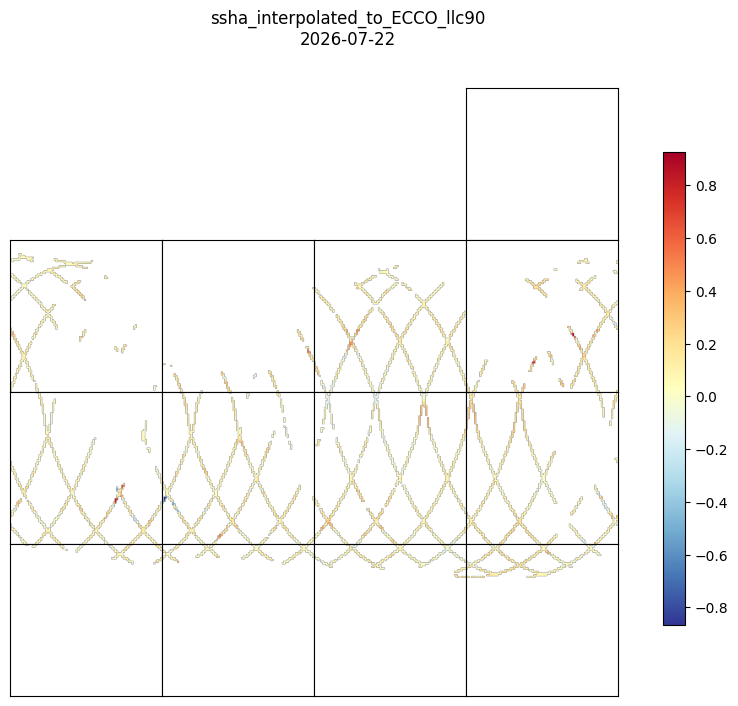

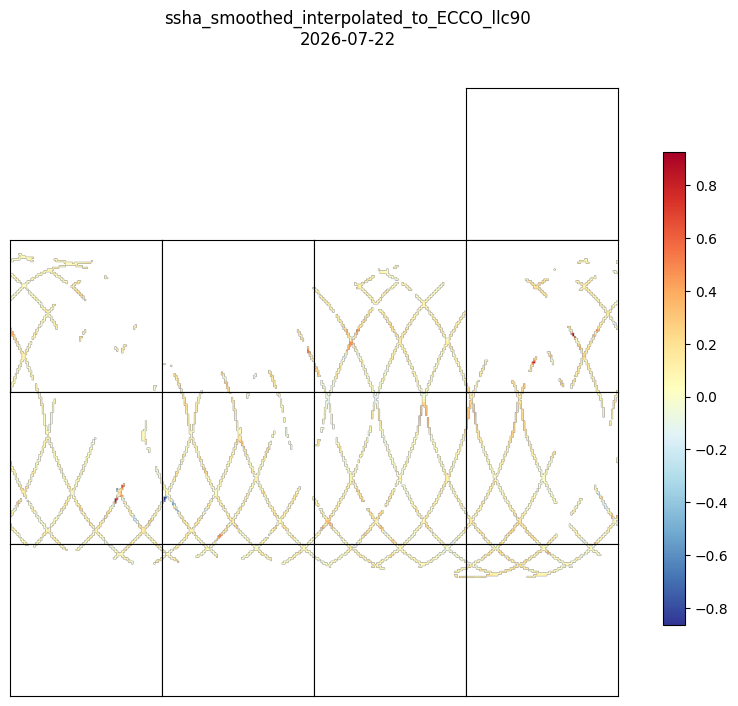

In [11]:
for field_ds in field_ds_list:
    plotting.make_plot(field_ds[0][list(field_ds[0].data_vars)[0]])
